# Работа по теме "Методы снижения размерности. Методы кластеризации"

## Описание

Работа предполагает самостоятельное исследование двух наборов данных. Основная задача - показать умение применять и интерпретировать методы снижения размерности данных и методы калстеризации.

Предлагаются два набора данных из различных областей.

Примерные критерии оценки:

- Данные изучены, предобработаны при необходимости.
- Применяются различные методы снижения размерности данных.
- Объяснены методы снижения размерности.
- Использованы различные методы кластеризации.
- Методы правильно объяснены и применены.
- Полученные кластеры корректно интерпертированы.

Итогом каждого исследования является кластеризация с подробной интерпретацией полученных кластеров.

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

## Анализ клиентов магазина

Датасет `Customer.csv` содержит синтетические данные о клиентах воображаемого магазина.

Набор данных состоит из 2000 записей и 8 столбцов:

- Идентификатор клиента
- Пол
- Возраст
- Годовой доход
- Оценка расходов — оценка, присваиваемая магазином на основе поведения покупателя и характера расходов.
- Профессия
- Опыт работы - в годах
- Размер семьи

Требуется помочь бизнесу лучше понять своих клиентов.

In [2]:
df_cust = pd.read_csv('Customers.csv')
df_cust.rename(columns={
    'Annual Income ($)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

print('Размер:', df_cust.shape)
df_cust.head()

Размер: (2000, 8)


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [3]:
df_cust.info()
print(df_cust.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       2000 non-null   int64 
 1   Gender           2000 non-null   object
 2   Age              2000 non-null   int64 
 3   Annual_Income    2000 non-null   int64 
 4   Spending_Score   2000 non-null   int64 
 5   Profession       1965 non-null   object
 6   Work Experience  2000 non-null   int64 
 7   Family Size      2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB
CustomerID          0
Gender              0
Age                 0
Annual_Income       0
Spending_Score      0
Profession         35
Work Experience     0
Family Size         0
dtype: int64


In [7]:
df_cust_processed = df_cust.copy()

mode_profession = df_cust_processed['Profession'].mode()[0]
df_cust_processed.loc[:, 'Profession'] = df_cust_processed['Profession'].fillna(mode_profession)

df_cust_processed = df_cust_processed.drop('CustomerID', axis=1)

categorical_features = ['Gender', 'Profession']
numerical_features = ['Age', 'Annual_Income', 'Spending_Score', 'Work Experience', 'Family Size']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_preprocessed = preprocessor.fit_transform(df_cust_processed)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_preprocessed)

print(f"Признаков изначально: {X_preprocessed.shape[1]}")
print(f"Признаков после PCA: {X_pca.shape[1]}")


Признаков изначально: 16
Признаков после PCA: 9


## KMeans


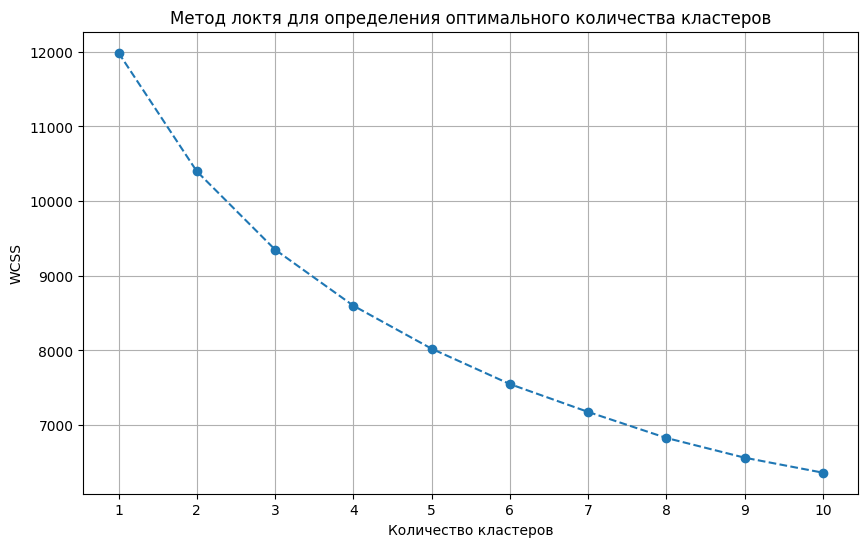

In [12]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Метод локтя для определения оптимального количества кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


In [13]:
n_clusters = 5

kmeans_model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_pca)

df_cust_processed['Cluster'] = clusters

print(f"Распределение клиентов по {n_clusters} кластерам:")
print(df_cust_processed['Cluster'].value_counts().sort_index())

Распределение клиентов по 5 кластерам:
Cluster
0    419
1    382
2    424
3    356
4    419
Name: count, dtype: int64


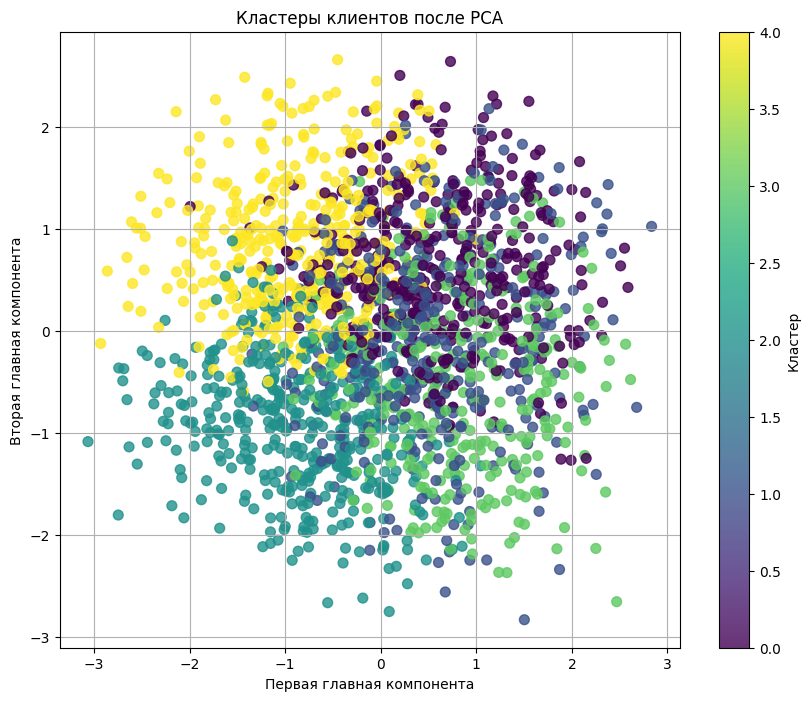

In [15]:
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.8)
plt.title('Кластеры KMeans')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(label='Кластер')
plt.grid(True)
plt.show()


## Agglomerative Clustering

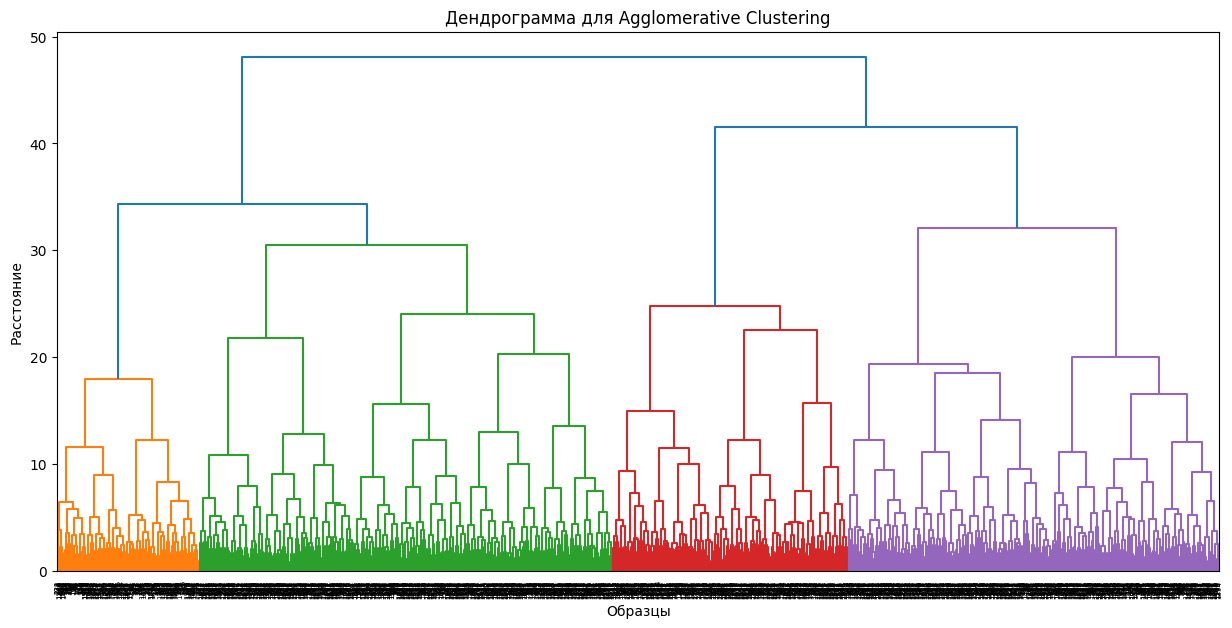

Распределение клиентов по 4 кластерам (Agglomerative Clustering):
Agglomerative_Cluster
0    638
1    711
2    406
3    245
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(15, 7))
dend = dendrogram(linkage(X_pca, method='ward'))
plt.title('Дендрограмма для Agglomerative Clustering')
plt.xlabel('Образцы')
plt.ylabel('Расстояние')
plt.show()

n_clusters_agg = 4

agg_clustering_model = AgglomerativeClustering(n_clusters=n_clusters_agg, metric='euclidean', linkage='ward')
agg_clusters = agg_clustering_model.fit_predict(X_pca)

df_cust_processed['Agglomerative_Cluster'] = agg_clusters

print(f"Распределение клиентов по {n_clusters_agg} кластерам (Agglomerative Clustering):")
print(df_cust_processed['Agglomerative_Cluster'].value_counts().sort_index())


## Климат и болезни

Датасет climate_disease_dataset.csv объединяет климатические, экологические, эпидемиологические и социально-экономические данные из 120 стран за 24 года (2000-2023). Целью является анализ взаимосвязи между изменением климата, загрязнением окружающей среды и распространением инфекционных заболеваний (малярия, лихорадка денге, холера, болезнь Лайма).

In [18]:
df_clim = pd.read_csv('climate_disease_dataset.csv')
print('Размер:', df_clim.shape)
df_clim.head()

Размер: (34560, 12)


,year,month,country,region,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
0,2000,1,Palestinian Territory,Central,28.132468,152.083870,110.487231,12.000000,53,145,113,1068
1,2000,2,Palestinian Territory,Central,30.886500,119.591418,83.467928,12.000000,132,48,113,1068
2,2000,3,Palestinian Territory,Central,31.366433,95.876124,93.095292,12.000000,34,80,113,1068
3,2000,4,Palestinian Territory,Central,28.481870,175.315731,105.530192,9.395894,23,133,113,1068
4,2000,5,Palestinian Territory,Central,26.890370,191.445990,60.205979,9.935726,39,74,113,1068


In [19]:
df_clim.info()
print('Пропуски:')
print(df_clim.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34560 entries, 0 to 34559
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                34560 non-null  int64  
 1   month               34560 non-null  int64  
 2   country             34560 non-null  object 
 3   region              34560 non-null  object 
 4   avg_temp_c          34560 non-null  float64
 5   precipitation_mm    34560 non-null  float64
 6   air_quality_index   34560 non-null  float64
 7   uv_index            34560 non-null  float64
 8   malaria_cases       34560 non-null  int64  
 9   dengue_cases        34560 non-null  int64  
 10  population_density  34560 non-null  int64  
 11  healthcare_budget   34560 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 3.2+ MB
Пропуски:
year                  0
month                 0
country               0
region                0
avg_temp_c            0
precipitation

In [21]:
num_cols_all = df_clim.select_dtypes(include=np.number).columns.tolist()
exclude_cols = ['year']
feature_cols = [c for c in num_cols_all if c not in exclude_cols]
print('Числовые признаки для анализа:')
print(feature_cols)
df_clim[feature_cols] = df_clim.groupby('country')[feature_cols].transform(
    lambda x: x.fillna(x.median())
)

df_country = df_clim.groupby('country', as_index=False).agg(
    Region = ('region', 'first'),
    **{col: (col, 'mean') for col in feature_cols}
)
print('Размер после агрегации (стран):', df_country.shape)
df_country.head()

Числовые признаки для анализа:
['month', 'avg_temp_c', 'precipitation_mm', 'air_quality_index', 'uv_index', 'malaria_cases', 'dengue_cases', 'population_density', 'healthcare_budget']
Размер после агрегации (стран): (120, 11)


,country,Region,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
0,American Samoa,East,6.5,20.129517,225.060643,10.543390,10.388125,63.993056,70.430556,289.0,4667.0
1,Antarctica (the territory South of 60 deg S),North,6.5,20.914754,88.238572,16.757147,10.664012,46.868056,64.447917,289.0,4256.0
2,Antigua and Barbuda,South,6.5,19.944344,234.316213,35.588115,10.544012,71.430556,79.364583,364.0,3077.0
3,Armenia,Central,6.5,18.213447,224.719973,20.214942,9.913392,63.277778,70.326389,178.0,4020.0
4,Aruba,North,6.5,14.303888,157.079155,19.740616,8.822024,50.197917,55.885417,478.0,3986.0


In [22]:
X_clim = df_country[feature_cols].copy()

scaler = StandardScaler()
X_clim_scaled = scaler.fit_transform(X_clim)
print('Форма масштабированной матрицы:', X_clim_scaled.shape)

Форма масштабированной матрицы: (120, 9)


In [24]:
pca_clim = PCA(n_components=2, random_state=42)
X_clim_pca = pca_clim.fit_transform(X_clim_scaled)

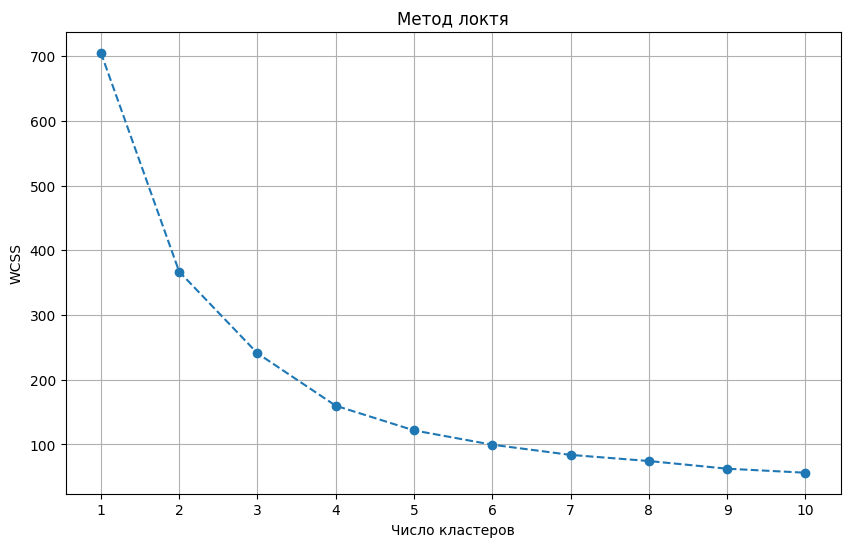

In [30]:
wcss_clim = []
for i in range(1, 11):
    kmeans_clim = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_clim.fit(X_clim_pca)
    wcss_clim.append(kmeans_clim.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_clim, marker='o', linestyle='--')
plt.title('Метод локтя')
plt.xlabel('Число кластеров')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Распределение стран по 3 KMeans кластерам:
KMeans_Cluster_Clim
0    47
1    42
2    31
Name: count, dtype: int64


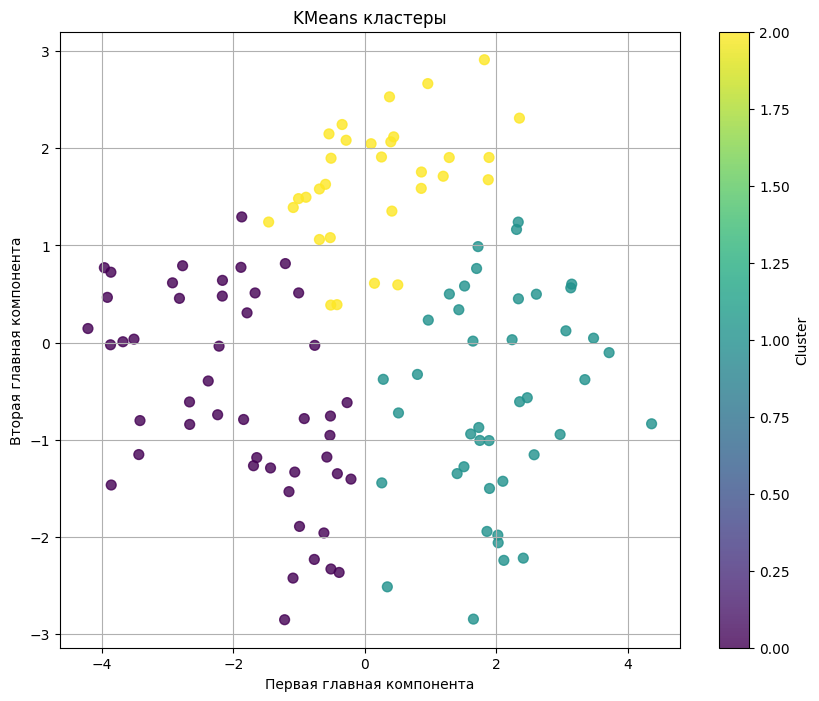

In [31]:
n_clusters_clim = 3

kmeans_clim_model = KMeans(n_clusters=n_clusters_clim, init='k-means++', random_state=42, n_init=10)
clusters_clim = kmeans_clim_model.fit_predict(X_clim_pca)

df_country['KMeans_Cluster_Clim'] = clusters_clim

print(f"Распределение стран по {n_clusters_clim} KMeans кластерам:")
print(df_country['KMeans_Cluster_Clim'].value_counts().sort_index())

plt.figure(figsize=(10, 8))
plt.scatter(X_clim_pca[:, 0], X_clim_pca[:, 1], c=clusters_clim, cmap='viridis', s=50, alpha=0.8)
plt.title('KMeans кластеры')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

## DBSCAN

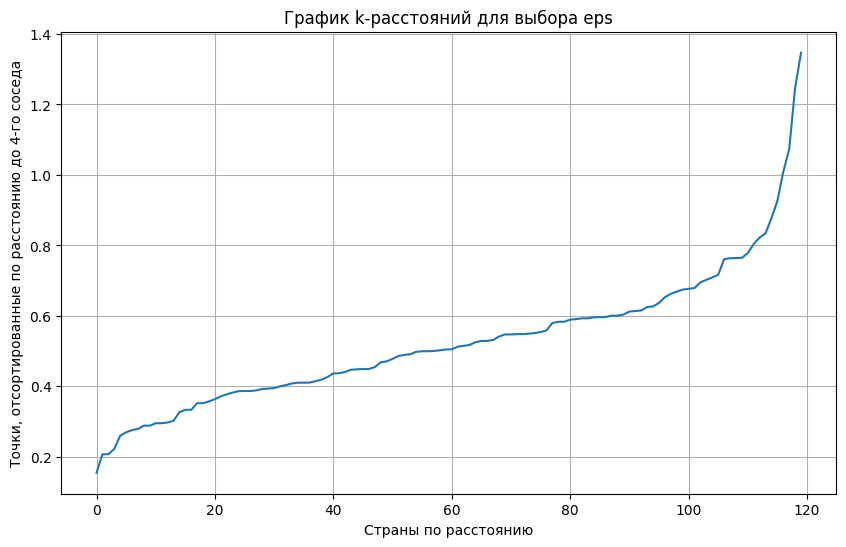

In [35]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_clim_pca)
distances, indices = neighbors_fit.kneighbors(X_clim_pca)

distances = np.sort(distances[:, 3], axis=0)
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('График k-расстояний для выбора eps')
plt.xlabel('Страны по расстоянию')
plt.ylabel('Точки, отсортированные по расстоянию до 4-го соседа')
plt.grid(True)
plt.show()

Распределение стран по DBSCAN кластерам (eps=0.3, min_samples=4):
DBSCAN_Cluster_Clim
-1    94
 0     4
 1     5
 2     5
 3     4
 4     4
 5     4
Name: count, dtype: int64


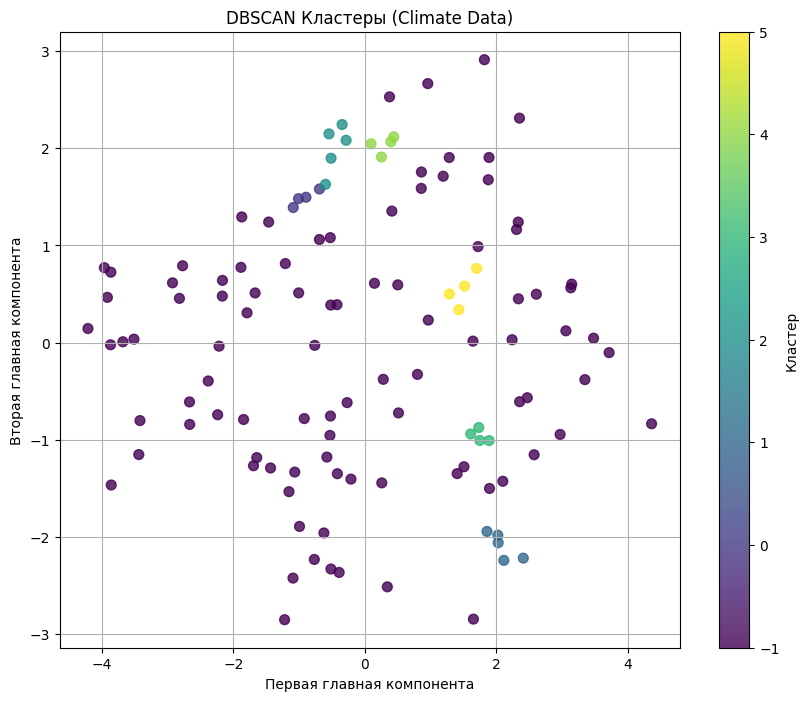

In [36]:
eps_clim = 0.3
min_samples_clim = 4

dbscan_clim_model = DBSCAN(eps=eps_clim, min_samples=min_samples_clim)
dbscan_clusters_clim = dbscan_clim_model.fit_predict(X_clim_pca)

df_country['DBSCAN_Cluster_Clim'] = dbscan_clusters_clim

print(f"Распределение стран по DBSCAN кластерам (eps={eps_clim}, min_samples={min_samples_clim}):")
print(df_country['DBSCAN_Cluster_Clim'].value_counts().sort_index())

plt.figure(figsize=(10, 8))
plt.scatter(X_clim_pca[:, 0], X_clim_pca[:, 1], c=dbscan_clusters_clim, cmap='viridis', s=50, alpha=0.8)
plt.title('DBSCAN Кластеры (Climate Data)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(label='Кластер')
plt.grid(True)
plt.show()

## Выводы

Ключевые выводы по задачам

#### 1. Анализ клиентов магазина

*   Предварительная обработка данных:
    *   Пропущенные значения в столбце 'Profession' были заполнены модой.
    *   Столбец 'CustomerID' был удален.
    *   Категориальные признаки ('Gender', 'Profession') были преобразованы с помощью OneHotEncoder, а числовые признаки ('Age', 'Annual_Income', 'Spending_Score', 'Work Experience', 'Family Size') масштабированы с использованием StandardScaler.

*   Снижение размерности (PCA):
    *   Применено метод главных компонент (PCA), который сократил количество признаков с 16 до 9, сохранив при этом около 95% дисперсии данных.

*   Кластеризация KMeans:
    *   Использован метод локтя для определения оптимального количества кластеров, который указал на 5 кластеров.
    *   Модель KMeans была применена с 5 кластерами к данным после PCA (`X_pca`).
    *   Кластеры были добавлены в DataFrame и визуализированы на графике рассеяния по первым двум главным компонентам.

*   Агломеративная кластеризация:
    *   Построена дендрограмма для визуального определения количества кластеров.
    *   Агломеративная кластеризация была применена с 4 кластерами к данным после PCA (`X_pca`).
    *   Результаты кластеризации были добавлены в DataFrame и показано распределение клиентов по кластерам.

#### 2. Анализ климата и заболеваний

*   Предварительная обработка данных:
    *   Данные были агрегированы по странам, усредняя числовые показатели за 24 года.
    *   Масштабирование числовых признаков выполнено с помощью StandardScaler.

*   Снижение размерности (PCA):
    *   Применено PCA для сокращения размерности до 2 главных компонент (`X_clim_pca`) для удобства визуализации.

*   Кластеризация KMeans:
    *   Метод локтя был применен для определения оптимального количества кластеров, который предложил 3 кластера.
    *   KMeans с 3 кластерами был применен к `X_clim_pca`.
    *   Результаты были добавлены в DataFrame и визуализированы, показывая распределение стран по кластерам.

*   Кластеризация DBSCAN:
    *   Был построен график k-расстояний для определения параметра `eps`.
    *   DBSCAN был применен с `eps=0.3` и `min_samples=4`.
    *   В результате DBSCAN было выявлено несколько небольших кластеров, при этом значительная часть данных была классифицирована как шумовые точки (-1), что свидетельствует о разреженности данных или о наличии большого количества выбросов для выбранных параметров.